# Anàlisi metodològica dels classificadors

Aquest notebook documenta els classificadors supervisats utilitzats per assignar subtipus CMS a partir de dades d'expressió gènica. L'objectiu és descriure el funcionament dels models, justificar-ne la selecció i analitzar-ne els elements interns més rellevants.

L'avaluació quantitativa dels models no forma part d'aquest notebook. Les mètriques, les matrius de confusió i els contrastos estadístics es presenten al notebook d'avaluació.

## 0. Fitxa tècnica del notebook

| Element | Descripció |
|---------|------------|
| Entrada | Dades preprocessades i etiquetes CMS |
| Models | Regressió Logística, Random Forest i SVM lineal |
| Sortides | Coeficients, importàncies de variables, vectors de suport i comparació metodològica |
| Fora d'abast | Mètriques finals, hipòtesis d'avaluació i contrastos estadístics |

In [1]:
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, _tree
from sklearn.utils.class_weight import compute_class_weight

sys.path.insert(0, str(Path(".").resolve().parent))
from src.gdc_utils import repo_root
from src.models import load_processed_data

ROOT = repo_root()
PROCESSED_DIR = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "data" / "models"
FIGURES_DIR = ROOT / "figures"

X_train, X_test, y_train, y_test = load_processed_data(PROCESSED_DIR)
gene_names = pd.read_csv(PROCESSED_DIR / "gene_names.csv").set_index("gene_id")["gene_name"].to_dict()

model_names = ["logistic_regression", "random_forest", "svm"]
models = {name: joblib.load(MODELS_DIR / f"{name}.joblib") for name in model_names}
classes = list(models["logistic_regression"].classes_)
cms_colors = {"CMS1": "#4C72B0", "CMS2": "#DD8452", "CMS3": "#55A868", "CMS4": "#C44E52"}

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Models disponibles: {model_names}")
print(f"Classes detectades: {classes}")

X_train: (296, 15625)  |  X_test: (74, 15625)
Models disponibles: ['logistic_regression', 'random_forest', 'svm']
Classes detectades: ['CMS1', 'CMS2', 'CMS3', 'CMS4']


## 1. Problema de modelatge

El problema de modelatge es formula com una tasca de classificació supervisada multiclasse. Cada mostra queda representada per un vector de valors d'expressió gènica, i el model ha d'assignar una de les quatre etiquetes CMS disponibles.

Aquest tipus de problema es caracteritza per una alta dimensionalitat, ja que el nombre de gens és molt superior al nombre de mostres. Aquesta relació condiciona la selecció dels classificadors, ja que cal utilitzar models capaços de treballar amb moltes variables i amb un risc controlat de sobreajust.

**Referència:** Alharbi, F., & Vakanski, A. (2022). Machine learning methods for cancer classification using gene expression data: A review. *Bioengineering*, 9(5), 220.

### 1.1. Classificadors seleccionats

S'han seleccionat tres classificadors amb propietats complementàries: Regressió Logística, Random Forest i Support Vector Machine lineal. La selecció permet comparar models lineals amb un model basat en arbres i analitzar diferents formes d'aprendre patrons a partir de dades d'alta dimensionalitat.

La Regressió Logística i el SVM lineal permeten estudiar fronteres de decisió lineals. Random Forest introdueix un enfocament no lineal basat en l'agregació de múltiples arbres de decisió. Aquesta combinació proporciona un benchmark interpretable i adequat per avaluar el comportament de diferents famílies de models.

### 1.2. Tractament del desbalanceig de classes

La distribució de classes s'ha caracteritzat prèviament al notebook d'exploració de dades. Com que les classes no tenen la mateixa representació, els models s'entrenen amb una estratègia de ponderació de classes.

El paràmetre `class_weight='balanced'` ajusta el pes de cada classe de manera inversament proporcional a la seva freqüència en el conjunt d'entrenament. Això fa que els errors en classes menys representades tinguin més pes durant l'aprenentatge:

$$w_c = \frac{n}{k \cdot n_c}$$

On $n$ és el nombre total de mostres, $k$ és el nombre de classes, i $n_c$ és el nombre de mostres de la classe $c$.

In [2]:
class_names = sorted(y_train.unique())
weights = compute_class_weight("balanced", classes=np.array(class_names), y=y_train)
counts = y_train.value_counts().sort_index()

weight_df = pd.DataFrame({
    "Classe": class_names,
    "Mostres train": [counts[c] for c in class_names],
    "Pes assignat": [round(w, 4) for w in weights],
}).set_index("Classe")
weight_df

,Mostres train,Pes assignat
Classe,,
CMS1,57,1.2982
CMS2,116,0.6379
CMS3,43,1.7209
CMS4,80,0.9250


## 2. Regressió Logística multinomial

La Regressió Logística multinomial és un model lineal per a classificació multiclasse. El model calcula una puntuació per a cada classe a partir d'una combinació lineal de les variables d'entrada. Posteriorment, aquestes puntuacions es transformen en probabilitats mitjançant la funció softmax.

En aquest projecte, cada gen actua com una variable d'entrada. Els coeficients del model indiquen la contribució de cada gen a la puntuació d'una classe determinada.

### 2.1. Formulació matemàtica

**Puntuació per a la classe $c$ i la mostra $i$:**

$$z_c = \beta_{0,c} + \sum_{j=1}^{p} \beta_{j,c} \, x_j$$

**Probabilitat via softmax:**

$$P(y = c \mid \mathbf{x}) = \frac{e^{z_c}}{\sum_{r=1}^{k} e^{z_r}}$$

On $x_j$ és el valor d'expressió del gen $j$, $\beta_{j,c}$ és el coeficient associat a aquest gen per a la classe $c$, $p$ és el nombre de gens i $k$ és el nombre de classes.

Un coeficient positiu incrementa la puntuació de la classe corresponent quan augmenta el valor del gen. Un coeficient negatiu redueix aquesta puntuació.

### 2.2. Hiperparàmetres principals

Els hiperparàmetres principals de la Regressió Logística són:

- **C**: controla la força de regularització. Valors més baixos impliquen més regularització.
- **penalty**: defineix el tipus de penalització aplicada als coeficients.
- **solver**: especifica l'algorisme d'optimització.
- **max_iter**: fixa el nombre màxim d'iteracions.
- **class_weight**: incorpora la ponderació de classes durant l'entrenament.

En aquest projecte, la configuració s'ha escollit per obtenir un model lineal interpretable i estable en un context d'alta dimensionalitat.

In [3]:
lr = models["logistic_regression"]
relevant = ["C", "penalty", "solver", "max_iter", "class_weight"]
params = {k: v for k, v in lr.get_params().items() if k in relevant}
pd.DataFrame(list(params.items()), columns=["Paràmetre", "Valor"]).set_index("Paràmetre")

,Valor
Paràmetre,
C,1.0
class_weight,balanced
max_iter,5000
penalty,deprecated
solver,lbfgs


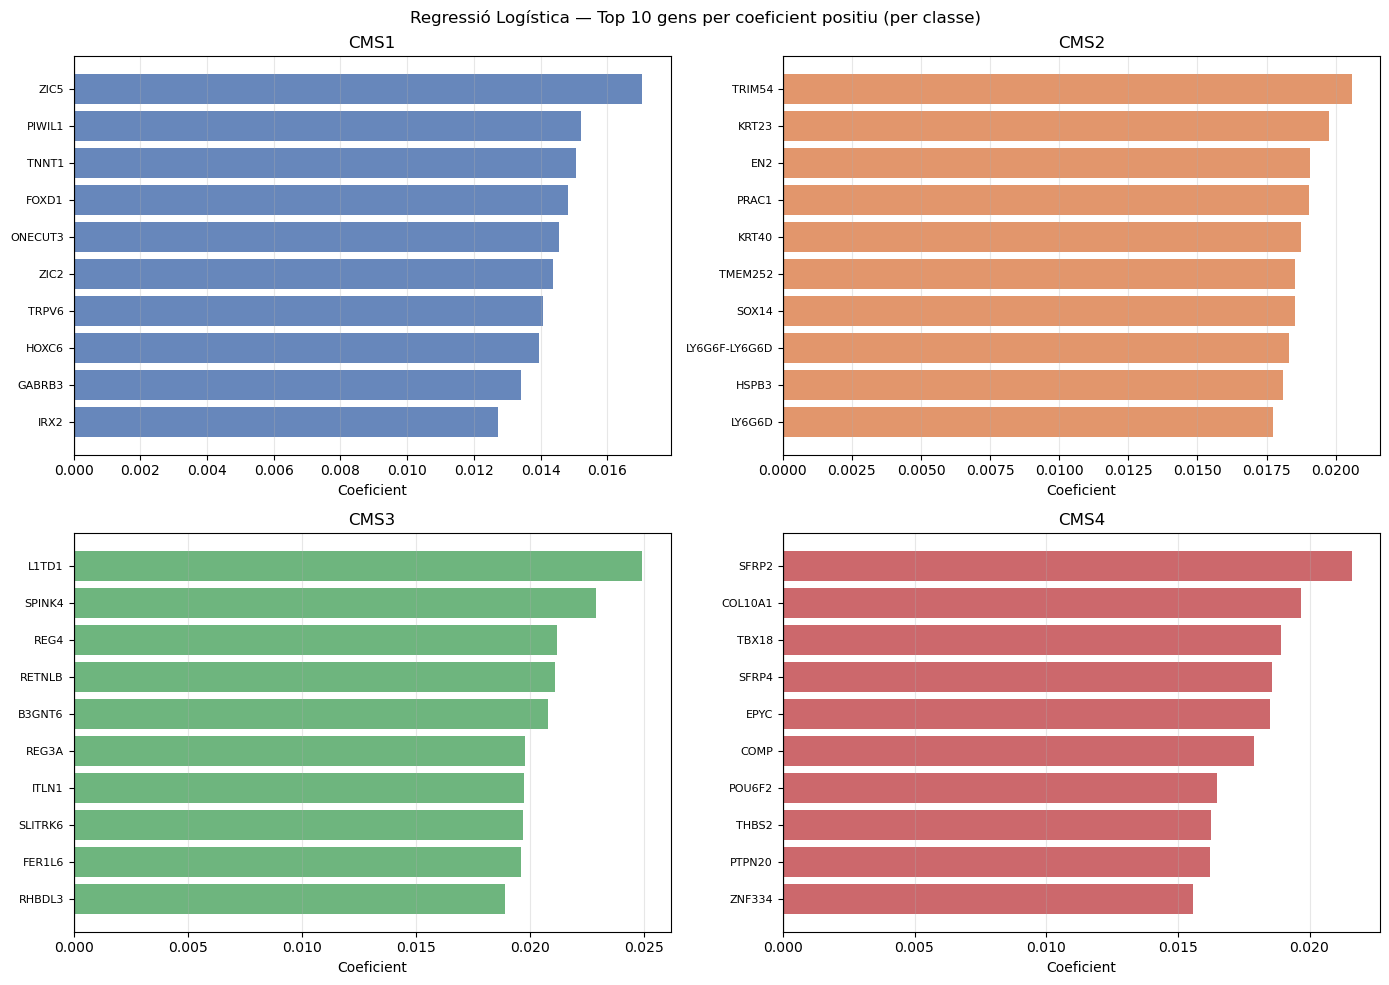

In [4]:
top_n = 10
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Regressió Logística — Top 10 gens per coeficient positiu (per classe)", fontsize=12)

for ax, cls in zip(axes.flatten(), classes):
    idx = list(lr.classes_).index(cls)
    coef = pd.Series(lr.coef_[idx], index=X_train.columns)
    top = coef.nlargest(top_n)
    labels = [gene_names.get(g, g) for g in top.index]
    ax.barh(range(top_n), top.values[::-1], color=cms_colors[cls], alpha=0.85)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(labels[::-1], fontsize=8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Coeficient")
    ax.set_title(cls)
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "lr_coefficients.png", dpi=150)
plt.show()

### 2.5. Interpretació del model

Els coeficients permeten analitzar quins gens contribueixen més a la puntuació de cada classe segons el model lineal. Aquesta interpretació s'ha de considerar com una explicació interna del classificador i no com una validació biològica dels gens.

La Regressió Logística és adequada en aquest context perquè pot utilitzar simultàniament totes les variables i manté una interpretació directa dels pesos apresos. La seva limitació principal és que defineix fronteres de decisió lineals i, per tant, pot no capturar relacions no lineals complexes entre gens.

## 3. Random Forest

Random Forest és un model d'ensemble basat en múltiples arbres de decisió. Cada arbre s'entrena sobre una mostra bootstrap del conjunt d'entrenament i utilitza una selecció parcial de variables en cada divisió. La predicció final s'obté agregant les prediccions dels arbres.

Aquest enfocament permet capturar relacions no lineals i reduir la variança respecte a un únic arbre de decisió.

**Referència:** Guinney, J., et al. (2015). The consensus molecular subtypes of colorectal cancer. *Nature Medicine*, 21(11), 1350–1356.

### 3.1. Agregació d'arbres

$$\hat{y} = \text{mode}\bigl(h_1(\mathbf{x}),\, h_2(\mathbf{x}),\, \ldots,\, h_T(\mathbf{x})\bigr)$$

On $h_t(\mathbf{x})$ és la predicció de l'arbre $t$ i $T$ és el nombre total d'arbres. En classificació, la classe final correspon a la classe més votada pels arbres de l'ensemble.

### 3.2. Hiperparàmetres principals

Els hiperparàmetres principals de Random Forest són:

- **n_estimators**: nombre d'arbres de l'ensemble.
- **max_depth**: profunditat màxima dels arbres.
- **max_features**: nombre de variables candidates en cada divisió.
- **min_samples_split**: nombre mínim de mostres per dividir un node.
- **min_samples_leaf**: nombre mínim de mostres en una fulla.
- **class_weight**: ponderació de classes.
- **random_state**: llavor per garantir reproduïbilitat.

Aquests hiperparàmetres controlen l'equilibri entre flexibilitat, variança i interpretabilitat.

In [5]:
rf = models["random_forest"]
relevant = ["n_estimators", "max_depth", "max_features", "min_samples_split", "min_samples_leaf", "class_weight", "random_state"]
params = {k: v for k, v in rf.get_params().items() if k in relevant}
pd.DataFrame(list(params.items()), columns=["Paràmetre", "Valor"]).set_index("Paràmetre")

,Valor
Paràmetre,
class_weight,balanced
max_depth,None
max_features,sqrt
min_samples_leaf,1
min_samples_split,2
n_estimators,500
random_state,42


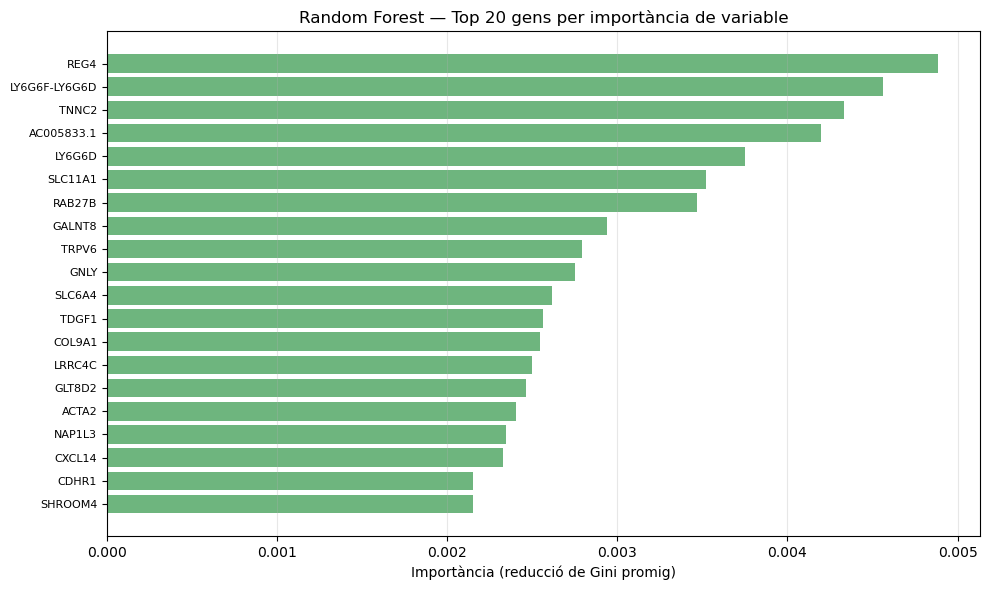

Importança acumulada del top 20: 6.1% del total


In [6]:
imp = pd.Series(rf.feature_importances_, index=X_train.columns)
top20 = imp.nlargest(20)
labels = [gene_names.get(g, g) for g in top20.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(20), top20.values[::-1], color="#55A868", alpha=0.85)
ax.set_yticks(range(20))
ax.set_yticklabels(labels[::-1], fontsize=8)
ax.set_xlabel("Importància (reducció de Gini promig)")
ax.set_title("Random Forest — Top 20 gens per importància de variable")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rf_feature_importance.png", dpi=150)
plt.show()

print(f"Importança acumulada del top 20: {top20.sum():.1%} del total")

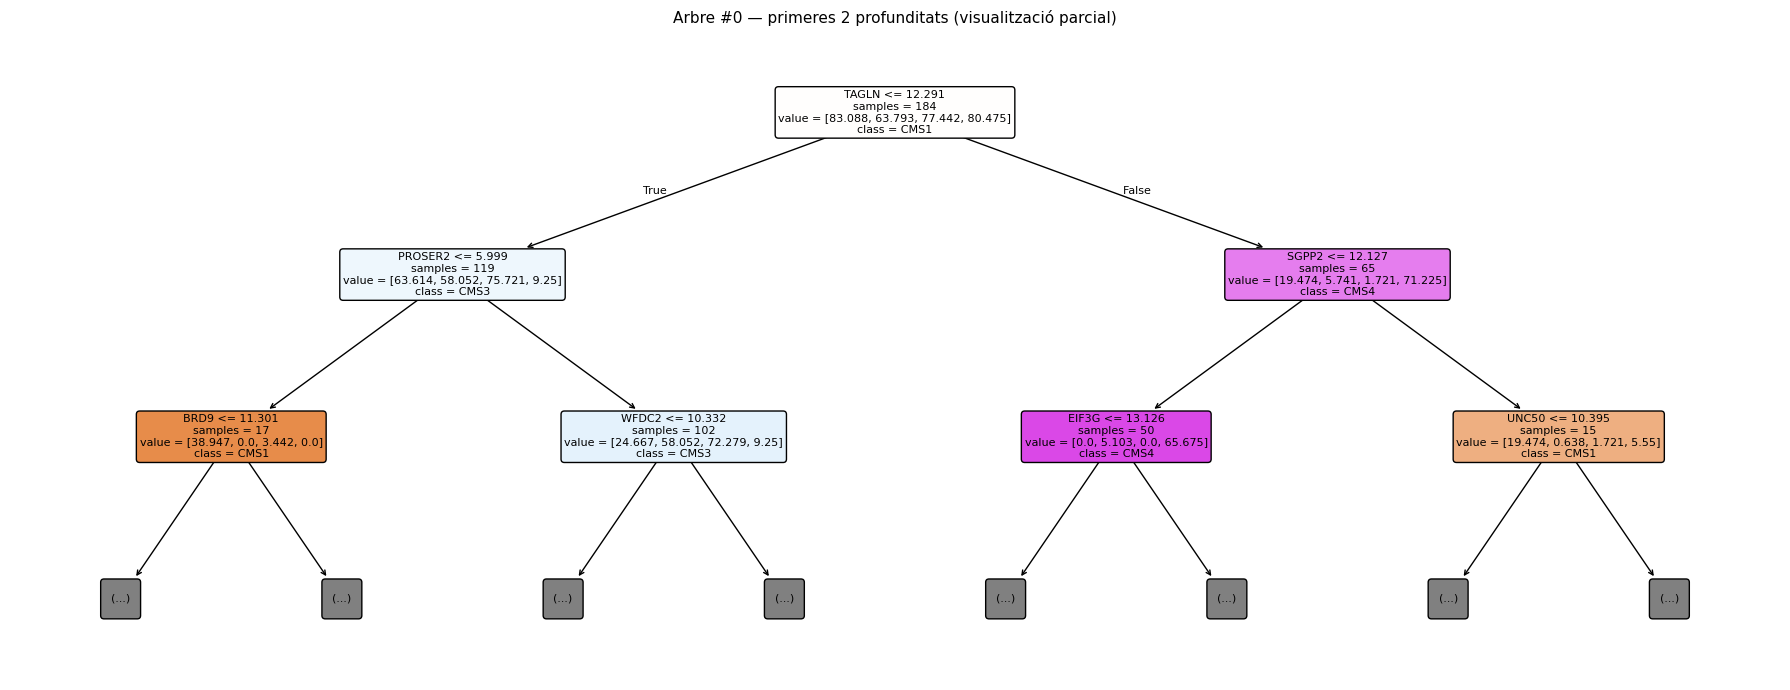

Camí de la mostra 1 (classe real: CMS2):
  Nivell 1: TAGLN = 13.51  (llindar 12.29) → dreta
  Nivell 2: SGPP2 = 11.23  (llindar 12.13) → esquerra
  Nivell 3: EIF3G = 12.81  (llindar 13.13) → esquerra
  Nivell 4: SNRPB = 12.58  (llindar 14.00) → esquerra
  Nivell 5: ZNF599 = 7.94  (llindar 8.25) → esquerra
  Predicció arbre #0: CMS4


In [7]:
tree = rf.estimators_[0]
feature_labels = [gene_names.get(g, g) for g in X_train.columns]

fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(
    tree,
    max_depth=2,
    feature_names=feature_labels,
    class_names=classes,
    filled=True,
    rounded=True,
    impurity=False,
    ax=ax,
    fontsize=8,
)
ax.set_title("Arbre #0 — primeres 2 profunditats (visualització parcial)", fontsize=11)
plt.tight_layout()
plt.show()

sample = X_test.iloc[0]
node = 0
tree_ = tree.tree_
print(f"Camí de la mostra 1 (classe real: {y_test.values[0]}):")
depth = 0
while tree_.feature[node] != _tree.TREE_UNDEFINED:
    feat_idx = tree_.feature[node]
    threshold = tree_.threshold[node]
    val = float(sample.values[feat_idx])
    direction = "esquerra" if val <= threshold else "dreta"
    print(f"  Nivell {depth+1}: {feature_labels[feat_idx]} = {val:.2f}  (llindar {threshold:.2f}) → {direction}")
    node = tree_.children_left[node] if val <= threshold else tree_.children_right[node]
    depth += 1
leaf_class = classes[int(tree_.value[node].argmax())]
print(f"  Predicció arbre #0: {leaf_class}")

### 3.6. Interpretació del model

La importància de variables indica quins gens han contribuït més a les divisions dels arbres de l'ensemble. Aquesta mesura és global i depèn de l'estructura del Random Forest.

L'avantatge principal del model és la capacitat de representar relacions no lineals. La seva limitació és que cada arbre utilitza només una part de les mostres i de les variables, fet que pot reduir l'estabilitat en conjunts amb moltes variables i un nombre moderat de mostres.

## 4. Support Vector Machine lineal

El Support Vector Machine lineal és un classificador que busca un hiperplà capaç de separar les classes maximitzant el marge entre les mostres més properes a la frontera de decisió.

En un problema multiclasse, el SVM lineal s'aplica mitjançant una estratègia One-vs-Rest, en què s'entrena un classificador per distingir cada classe respecte a la resta.

### 4.1. Formulació matemàtica

$$f(\mathbf{x}) = \mathbf{w}^\top \mathbf{x} + b$$

El signe i la magnitud de $f(\mathbf{x})$ indiquen la posició de la mostra respecte a l'hiperplà de decisió. En la formulació lineal, $\mathbf{w}$ representa el vector de pesos i $b$ el terme independent.

Les mostres més properes a la frontera són els vectors de suport. Aquestes mostres tenen un paper determinant en la definició del marge.

### 4.2. Hiperparàmetres principals

Els hiperparàmetres principals del SVM lineal són:

- **C**: controla el compromís entre maximitzar el marge i penalitzar errors.
- **kernel**: defineix el tipus de frontera de decisió. En aquest projecte s'utilitza kernel lineal.
- **class_weight**: ponderació de classes.
- **probability**: indica si es calculen probabilitats calibrades.
- **tol**: tolerància del criteri d'aturada.
- **max_iter**: nombre màxim d'iteracions.

L'ús d'un kernel lineal és coherent amb l'objectiu d'obtenir un model interpretable i adequat per a dades d'alta dimensionalitat.

In [8]:
svm = models["svm"]
relevant = ["C", "kernel", "class_weight", "probability", "tol", "max_iter"]
params = {k: v for k, v in svm.get_params().items() if k in relevant}
pd.DataFrame(list(params.items()), columns=["Paràmetre", "Valor"]).set_index("Paràmetre")

,Valor
Paràmetre,
C,1.0
class_weight,balanced
kernel,linear
max_iter,-1
probability,True
tol,0.001


In [9]:
sv_df = pd.DataFrame({
    "Classe": list(svm.classes_),
    "Vectors de suport": list(svm.n_support_),
    "% del train": [round(n / len(X_train) * 100, 1) for n in svm.n_support_],
}).set_index("Classe")

print(f"Total vectors de suport (OvR): {svm.n_support_.sum()}")
print(f"% total sobre el train set:    {svm.n_support_.sum() / len(X_train) * 100:.1f}%")
sv_df

Total vectors de suport (OvR): 180
% total sobre el train set:    60.8%


,Vectors de suport,% del train
Classe,,
CMS1,36,12.2
CMS2,66,22.3
CMS3,31,10.5
CMS4,47,15.9


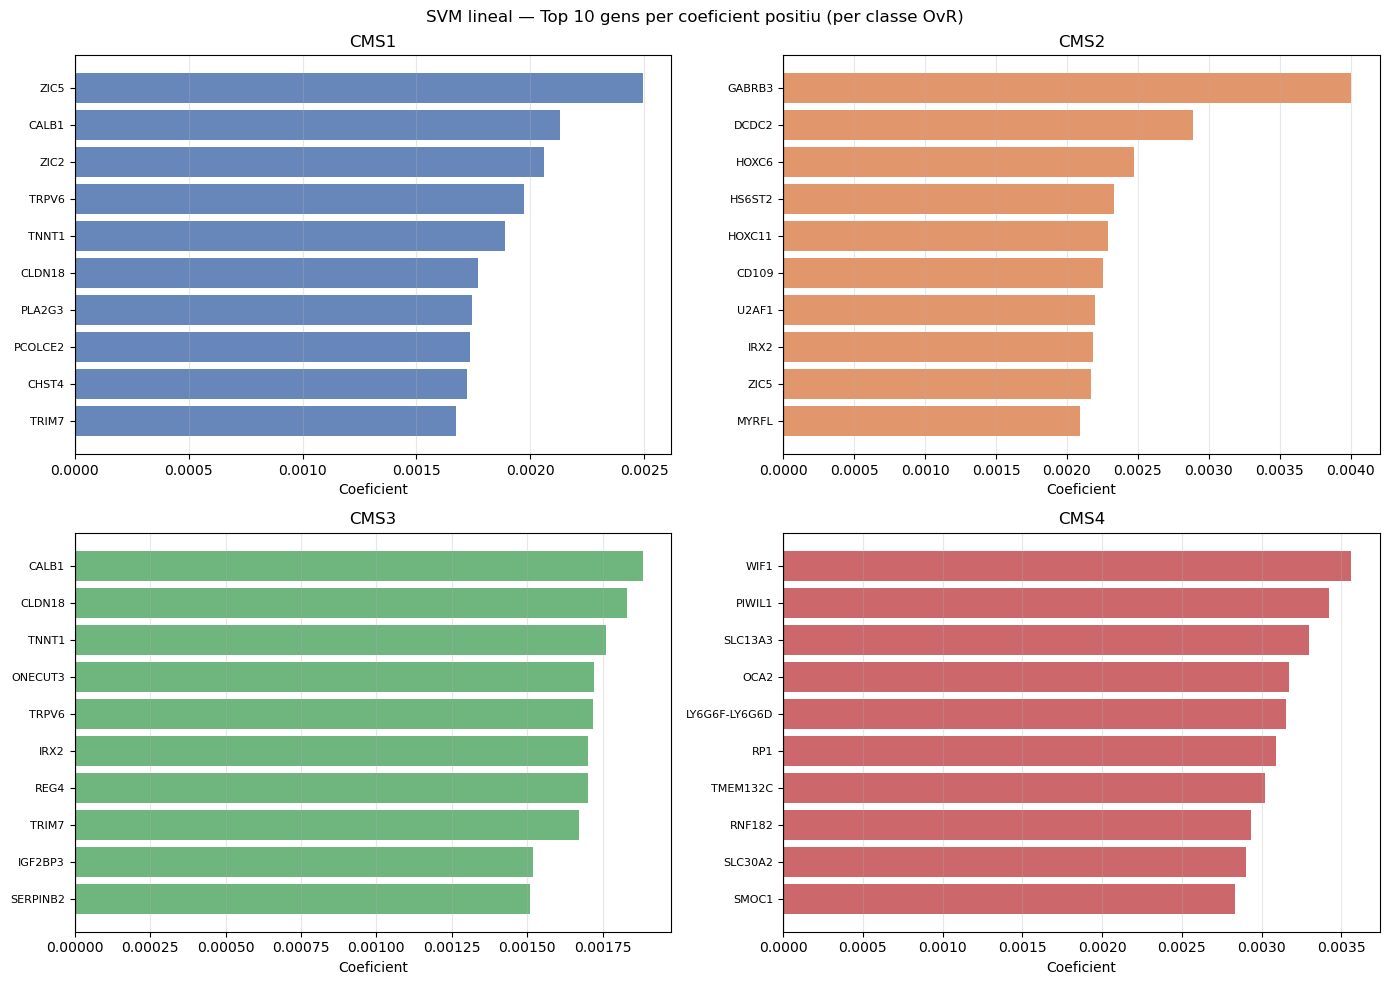

,CMS1,CMS2,CMS3,CMS4,Predicció,Real
Mostra 1,-0.272,3.275,0.786,2.199,CMS2,CMS2
Mostra 2,3.226,-0.235,1.081,1.989,CMS1,CMS1
Mostra 3,0.819,2.222,-0.226,3.188,CMS4,CMS4
Mostra 4,3.254,-0.268,0.792,2.240,CMS1,CMS1
Mostra 5,-0.226,3.242,2.179,0.790,CMS2,CMS2


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("SVM lineal — Top 10 gens per coeficient positiu (per classe OvR)", fontsize=12)

for ax, cls in zip(axes.flatten(), classes):
    idx = list(svm.classes_).index(cls)
    coef = pd.Series(svm.coef_[idx], index=X_train.columns)
    top = coef.nlargest(10)
    labels = [gene_names.get(g, g) for g in top.index]
    ax.barh(range(10), top.values[::-1], color=cms_colors[cls], alpha=0.85)
    ax.set_yticks(range(10))
    ax.set_yticklabels(labels[::-1], fontsize=8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Coeficient")
    ax.set_title(cls)
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "svm_coefficients.png", dpi=150)
plt.show()

dec_scores = svm.decision_function(X_test.iloc[:5])
dec_df = pd.DataFrame(dec_scores, columns=svm.classes_,
                      index=[f"Mostra {i+1}" for i in range(5)])
dec_df["Predicció"] = svm.predict(X_test.iloc[:5])
dec_df["Real"] = y_test.values[:5]
dec_df.round(3)

### 4.6. Interpretació del model

Els coeficients del SVM lineal indiquen la contribució de cada variable a la funció de decisió. Igual que en la Regressió Logística, aquesta interpretació correspon al comportament intern del model i no equival a una validació biològica dels gens.

El SVM lineal és adequat per a dades d'alta dimensionalitat perquè pot definir fronteres de decisió en espais amb moltes variables. La seva limitació principal és que el paràmetre C condiciona fortament l'equilibri entre marge i errors de classificació.

## 5. Comparació metodològica dels classificadors

Els tres classificadors presenten propietats complementàries. La Regressió Logística i el SVM lineal comparteixen una estructura lineal i permeten interpretar pesos associats a les variables. Random Forest, en canvi, utilitza arbres de decisió i pot capturar relacions no lineals.

Aquesta comparació no determina quin model té millor rendiment. La seva funció és establir les diferències metodològiques que posteriorment es contrasten en el notebook d'avaluació.

In [11]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVM lineal"],
    "Tipus": ["Lineal", "Ensemble arbres", "Lineal marge màxim"],
    "Interpretabilitat": ["Alta", "Mitjana", "Mitjana"],
    "Relacions no lineals": ["No", "Sí", "No"],
    "Adequat alta dim.": ["Sí", "Parcial", "Sí"],
    "Risc principal": ["Simplificació lineal", "Variabilitat / fragmentació", "Sensibilitat a C"],
}).set_index("Model")
comparison

,Tipus,Interpretabilitat,Relacions no lineals,Adequat alta dim.,Risc principal
Model,,,,,
Logistic Regression,Lineal,Alta,No,Sí,Simplificació lineal
Random Forest,Ensemble arbres,Mitjana,Sí,Parcial,Variabilitat / fragmentació
SVM lineal,Lineal marge màxim,Mitjana,No,Sí,Sensibilitat a C


## 6. Conclusions metodològiques

Aquest notebook ha documentat el funcionament i la configuració dels tres classificadors utilitzats. La Regressió Logística i el SVM lineal proporcionen enfocaments lineals interpretables, mentre que Random Forest aporta una alternativa no lineal basada en arbres.

Les diferències metodològiques observades entre els models permeten establir criteris d'anàlisi per a l'avaluació posterior. La comparació quantitativa, la formulació d'hipòtesis i la seva resolució es desenvolupen al notebook d'avaluació de resultats.